# Respomuso availability snapshots

Notebook para inspeccionar `data/availability.sqlite`: estado actual, historico de busquedas y evolucion de plazas disponibles por fecha.

In [22]:
from pathlib import Path
import sqlite3
from zoneinfo import ZoneInfo

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

DB_CANDIDATES = [Path('data/availability.sqlite'), Path('../data/availability.sqlite')]
DB_PATH = next((path for path in DB_CANDIDATES if path.exists()), DB_CANDIDATES[0])
LOCAL_TZ = ZoneInfo('Europe/Madrid')
ALERT_DATES = []  # Example: ['2026-07-12', '2026-07-14']; empty means only DB data is shown.

DB_PATH.resolve()


PosixPath('/home/pruiz/workspace/refugio/data/availability.sqlite')

## Load snapshots

In [23]:
if not DB_PATH.exists():
    raise FileNotFoundError(f'Database not found: {DB_PATH.resolve()}')

with sqlite3.connect(DB_PATH) as conn:
    tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type = 'table'", conn)['name'].tolist()
    if 'availability_snapshots' not in tables:
        raise ValueError('Table availability_snapshots not found. Run monitor.py once with the new schema.')
    snapshots = pd.read_sql_query(
        '''
        SELECT id, checked_at, target_date, status, is_available, available_places, raw_payload
        FROM availability_snapshots
        ORDER BY checked_at, target_date
        ''',
        conn,
    )

snapshots['checked_at_utc'] = pd.to_datetime(snapshots['checked_at'], utc=True, errors='coerce')
snapshots['checked_at_local'] = snapshots['checked_at_utc'].dt.tz_convert(LOCAL_TZ)
snapshots['is_alert_date'] = snapshots['target_date'].isin(ALERT_DATES) if ALERT_DATES else False
snapshots


,id,checked_at,target_date,status,is_available,available_places,raw_payload,checked_at_utc,checked_at_local,is_alert_date
0,1,2026-05-25T14:10:58+00:00,2026-06-01,green,1,5,"{""rooms"": [{""estado"": 1, ""fecha"": ""2026-06-01""...",2026-05-25 14:10:58+00:00,2026-05-25 16:10:58+02:00,False
1,2,2026-05-25T14:10:58+00:00,2026-06-02,green,1,18,"{""rooms"": [{""estado"": 1, ""fecha"": ""2026-06-02""...",2026-05-25 14:10:58+00:00,2026-05-25 16:10:58+02:00,False
2,3,2026-05-25T14:10:58+00:00,2026-06-03,green,1,12,"{""rooms"": [{""estado"": 1, ""fecha"": ""2026-06-03""...",2026-05-25 14:10:58+00:00,2026-05-25 16:10:58+02:00,False
3,4,2026-05-25T14:10:58+00:00,2026-06-04,green,1,9,"{""rooms"": [{""estado"": 1, ""fecha"": ""2026-06-04""...",2026-05-25 14:10:58+00:00,2026-05-25 16:10:58+02:00,False
4,5,2026-05-25T14:10:58+00:00,2026-06-05,green,1,2,"{""rooms"": [{""estado"": 1, ""fecha"": ""2026-06-05""...",2026-05-25 14:10:58+00:00,2026-05-25 16:10:58+02:00,False
...,...,...,...,...,...,...,...,...,...,...
971,972,2026-05-25T14:23:46+00:00,2026-09-26,green,1,47,"{""rooms"": [{""estado"": 1, ""fecha"": ""2026-09-26""...",2026-05-25 14:23:46+00:00,2026-05-25 16:23:46+02:00,False
972,973,2026-05-25T14:23:46+00:00,2026-09-27,green,1,57,"{""rooms"": [{""estado"": 1, ""fecha"": ""2026-09-27""...",2026-05-25 14:23:46+00:00,2026-05-25 16:23:46+02:00,False
973,974,2026-05-25T14:23:46+00:00,2026-09-28,green,1,70,"{""rooms"": [{""estado"": 1, ""fecha"": ""2026-09-28""...",2026-05-25 14:23:46+00:00,2026-05-25 16:23:46+02:00,False
974,975,2026-05-25T14:23:46+00:00,2026-09-29,green,1,70,"{""rooms"": [{""estado"": 1, ""fecha"": ""2026-09-29""...",2026-05-25 14:23:46+00:00,2026-05-25 16:23:46+02:00,False


## Current status

In [24]:
current = (
    snapshots.sort_values(['target_date', 'checked_at_utc', 'id'])
    .groupby('target_date', as_index=False)
    .tail(1)
    .sort_values('target_date')
    [['target_date', 'status', 'is_available', 'available_places', 'checked_at_local', 'is_alert_date']]
)
current


,target_date,status,is_available,available_places,checked_at_local,is_alert_date
854,2026-06-01,green,1,5,2026-05-25 16:23:46+02:00,False
855,2026-06-02,green,1,18,2026-05-25 16:23:46+02:00,False
856,2026-06-03,green,1,12,2026-05-25 16:23:46+02:00,False
857,2026-06-04,green,1,9,2026-05-25 16:23:46+02:00,False
858,2026-06-05,green,1,2,2026-05-25 16:23:46+02:00,False
...,...,...,...,...,...,...
971,2026-09-26,green,1,47,2026-05-25 16:23:46+02:00,False
972,2026-09-27,green,1,57,2026-05-25 16:23:46+02:00,False
973,2026-09-28,green,1,70,2026-05-25 16:23:46+02:00,False
974,2026-09-29,green,1,70,2026-05-25 16:23:46+02:00,False


In [25]:
summary = (
    current.groupby('status', dropna=False)
    .agg(dates=('target_date', 'count'), total_available_places=('available_places', 'sum'))
    .reset_index()
)
summary

,status,dates,total_available_places
0,green,69,2062
1,red,53,0


## Availability timeline

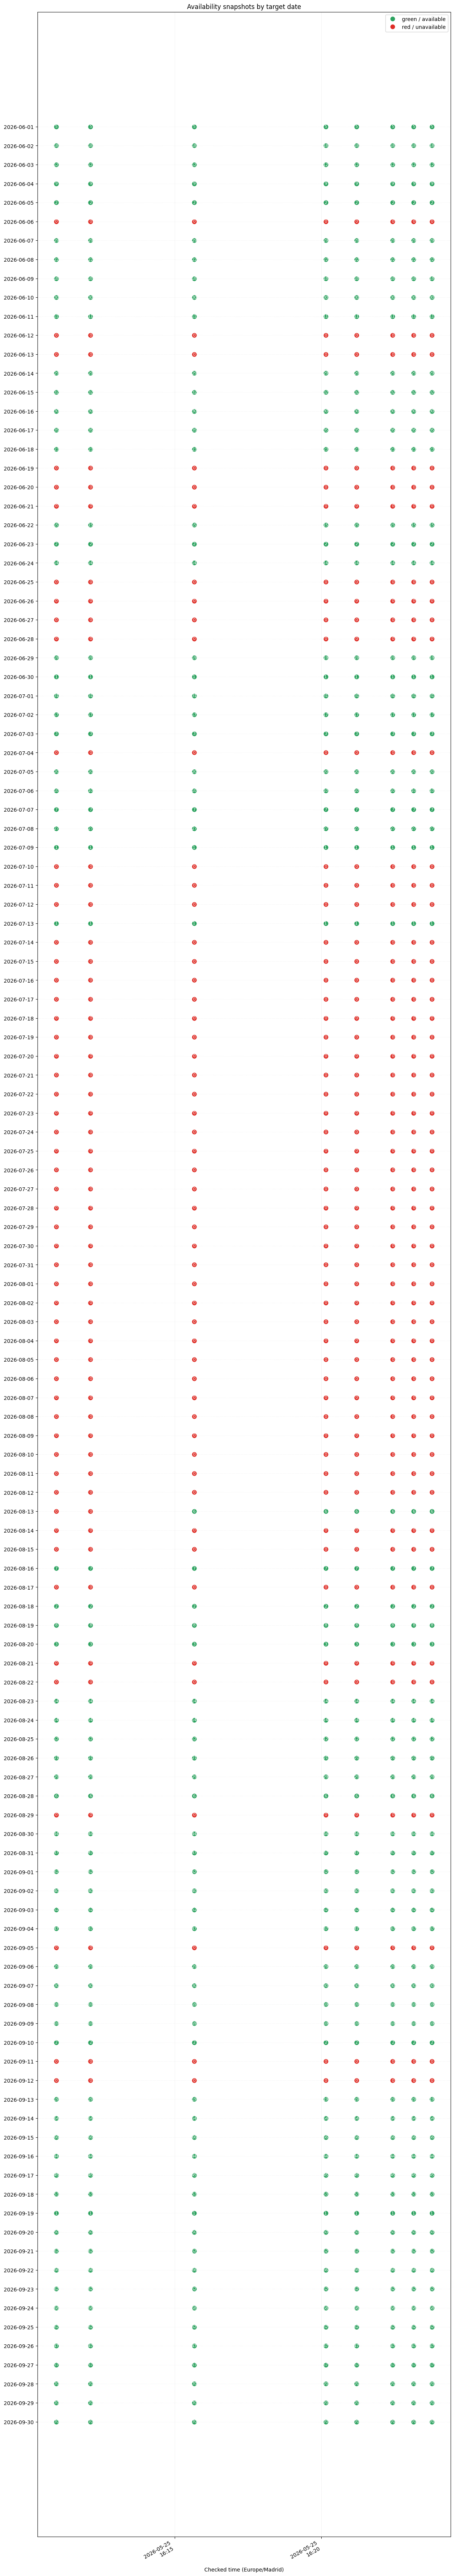

In [26]:
if snapshots.empty:
    raise ValueError('No availability snapshots found')

plot_df = snapshots.copy()
dates = list(plot_df['target_date'].drop_duplicates())
ypos = {date: idx for idx, date in enumerate(dates)}
colors = {'green': '#2ca25f', 'red': '#de2d26'}

fig_height = max(3, 0.55 * len(dates) + 1.5)
fig, ax = plt.subplots(figsize=(12, fig_height), constrained_layout=True)

for _, row in plot_df.iterrows():
    x = row['checked_at_local']
    y = ypos[row['target_date']]
    size = 130 if row['is_alert_date'] else 90
    ax.scatter(
        x,
        y,
        s=size,
        color=colors.get(row['status'], '#999999'),
        edgecolor='black' if row['is_alert_date'] else 'white',
        linewidth=1.2 if row['is_alert_date'] else 0.5,
        zorder=3,
    )
    ax.text(x, y, str(int(row['available_places'])), ha='center', va='center', color='white', fontsize=8, zorder=4)

ax.set_yticks(range(len(dates)))
ax.set_yticklabels(dates)
ax.set_xlabel(f'Checked time ({LOCAL_TZ.key})')
ax.set_title('Availability snapshots by target date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M', tz=LOCAL_TZ))
ax.grid(axis='x', linestyle=':', alpha=0.4)
ax.grid(axis='y', linestyle=':', alpha=0.2)
ax.invert_yaxis()

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['green'], markersize=10, label='green / available'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors['red'], markersize=10, label='red / unavailable'),
]
ax.legend(handles=legend_handles, loc='upper right')
fig.autofmt_xdate()


## Available places over time

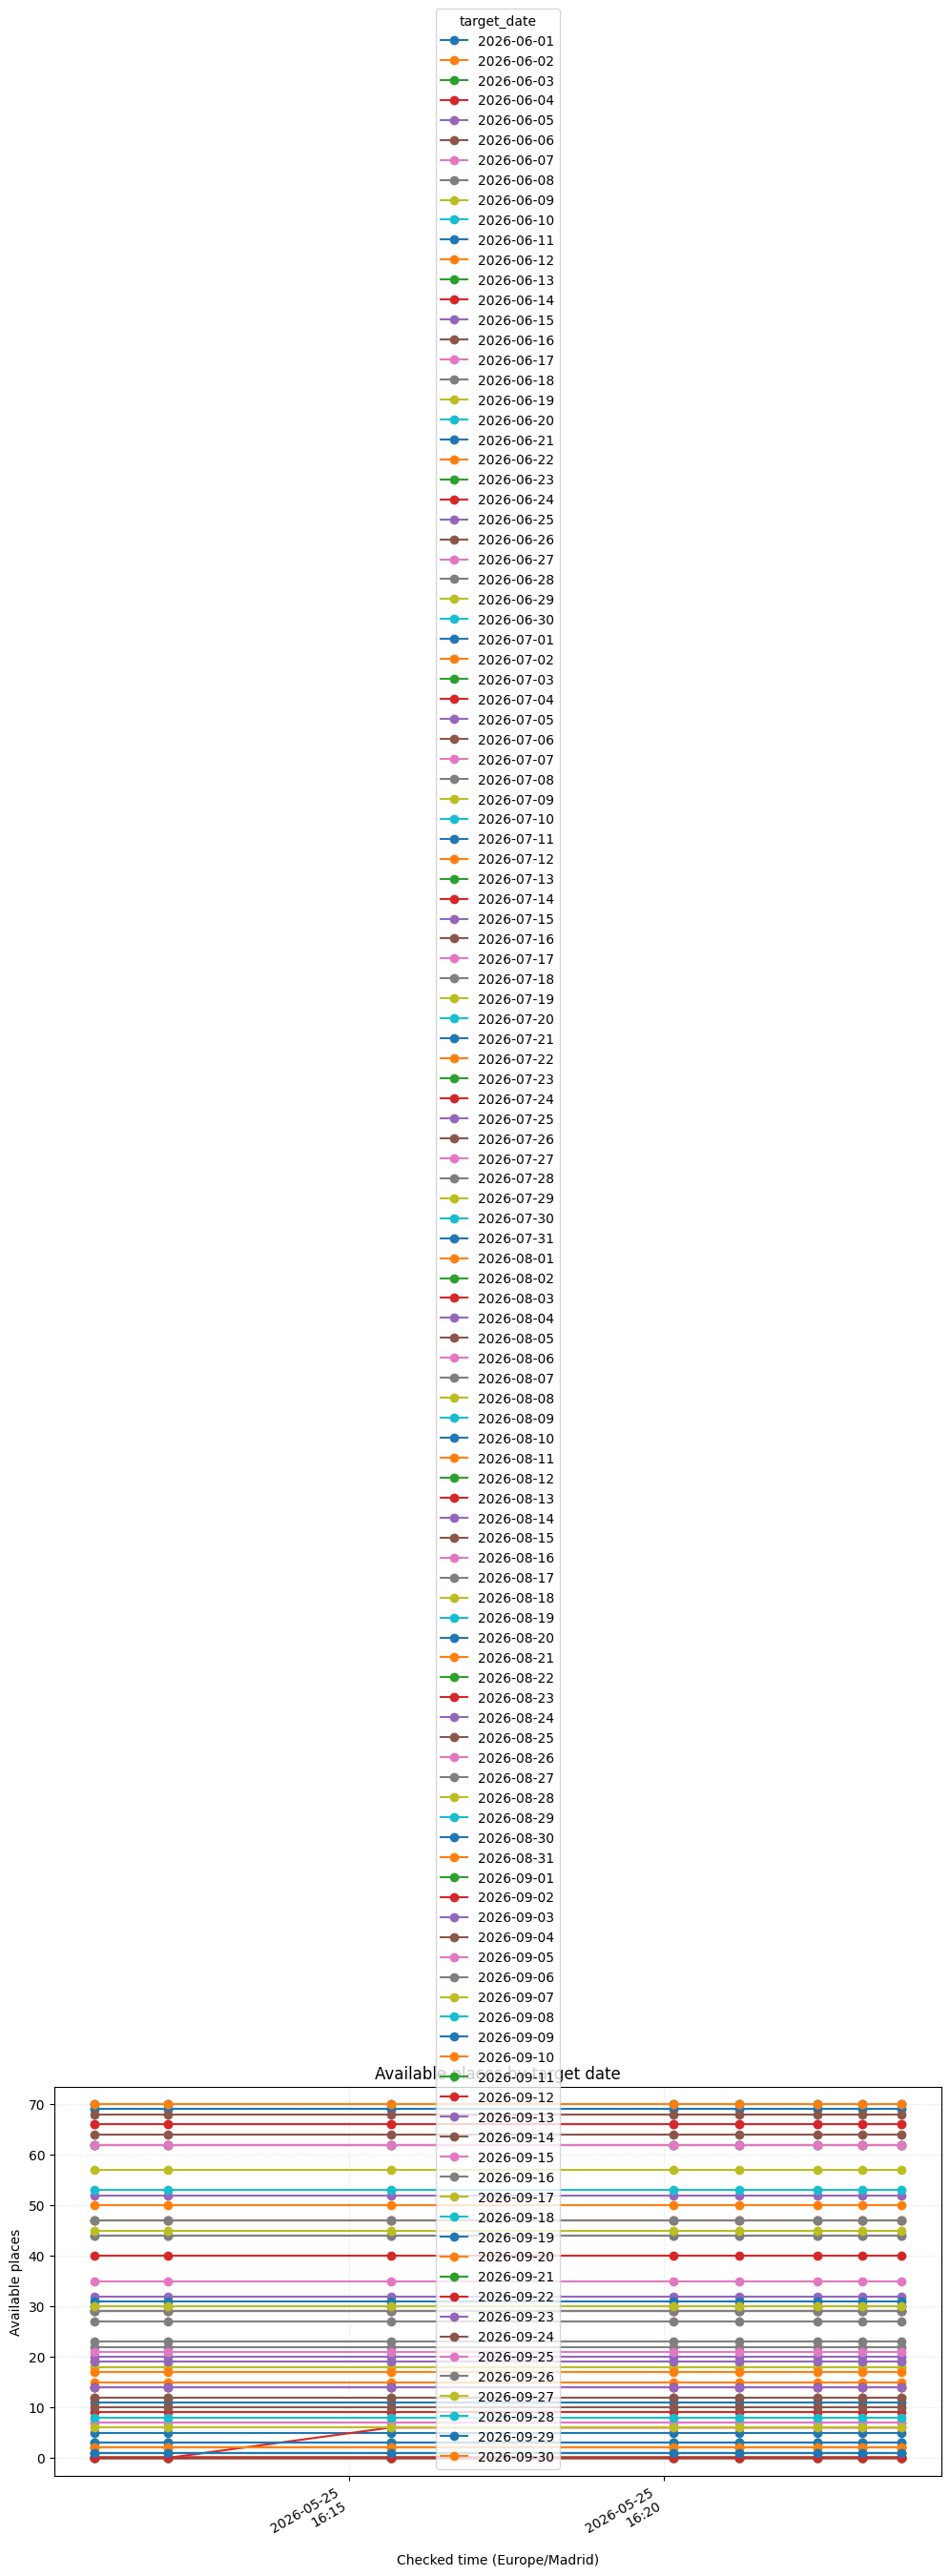

In [27]:
pivot = snapshots.pivot_table(
    index='checked_at_local',
    columns='target_date',
    values='available_places',
    aggfunc='last',
)

ax = pivot.plot(figsize=(12, 6), marker='o')
ax.set_title('Available places by target date')
ax.set_xlabel(f'Checked time ({LOCAL_TZ.key})')
ax.set_ylabel('Available places')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d\n%H:%M', tz=LOCAL_TZ))
ax.grid(True, linestyle=':', alpha=0.4)


## Full snapshot table

In [28]:
snapshots.drop(columns=['raw_payload']).sort_values(['checked_at_utc', 'target_date'])


,id,checked_at,target_date,status,is_available,available_places,checked_at_utc,checked_at_local,is_alert_date
0,1,2026-05-25T14:10:58+00:00,2026-06-01,green,1,5,2026-05-25 14:10:58+00:00,2026-05-25 16:10:58+02:00,False
1,2,2026-05-25T14:10:58+00:00,2026-06-02,green,1,18,2026-05-25 14:10:58+00:00,2026-05-25 16:10:58+02:00,False
2,3,2026-05-25T14:10:58+00:00,2026-06-03,green,1,12,2026-05-25 14:10:58+00:00,2026-05-25 16:10:58+02:00,False
3,4,2026-05-25T14:10:58+00:00,2026-06-04,green,1,9,2026-05-25 14:10:58+00:00,2026-05-25 16:10:58+02:00,False
4,5,2026-05-25T14:10:58+00:00,2026-06-05,green,1,2,2026-05-25 14:10:58+00:00,2026-05-25 16:10:58+02:00,False
...,...,...,...,...,...,...,...,...,...
971,972,2026-05-25T14:23:46+00:00,2026-09-26,green,1,47,2026-05-25 14:23:46+00:00,2026-05-25 16:23:46+02:00,False
972,973,2026-05-25T14:23:46+00:00,2026-09-27,green,1,57,2026-05-25 14:23:46+00:00,2026-05-25 16:23:46+02:00,False
973,974,2026-05-25T14:23:46+00:00,2026-09-28,green,1,70,2026-05-25 14:23:46+00:00,2026-05-25 16:23:46+02:00,False
974,975,2026-05-25T14:23:46+00:00,2026-09-29,green,1,70,2026-05-25 14:23:46+00:00,2026-05-25 16:23:46+02:00,False
